# 02 · Residual MLP & Depth × Width Ablation
**Deep Residual MLP for Diabetes Risk Prediction (CDC BRFSS 2015, PyTorch)**  
*Sections 6-7* · MSc Data Science project · Dr. Spoorthi H S

**In this notebook**
- Residual MLP: 21 → 512 × 5 residual blocks → 1 with BatchNorm, GELU and dropout (2.78 M parameters)
- Focal loss, training utilities and early stopping
- 20-configuration depth × width ablation: all within 0.003 AUC (0.9006-0.9036)

> **How to use these notebooks.** The outputs below come from one complete run of the pipeline. Each part builds on objects created earlier (data splits, the trained model, chosen thresholds), so the part notebooks are for reading and review. To reproduce the results, run [`00_full_pipeline_run_all.ipynb`](00_full_pipeline_run_all.ipynb) top to bottom.

[← Data, Leakage-Free Preprocessing & EDA](01_data_preprocessing_and_eda.ipynb) · [Training & Clinical Threshold Optimisation →](03_training_and_threshold_optimisation.ipynb)

---

---
## 6. Model Architecture — Clinical Deep MLP <a id='sec6'></a>

```
Input [B, 21]
    │
    ▼
 Linear(21 → 512) → BN → GELU → Dropout(0.15)
    │
    ├──[ResidualBlock × 5]──────────────────────┐
    │   Linear(512→512) → BN → GELU → Drop(0.3)│
    │   Linear(512→512) → BN                   │
    │   + skip → GELU                           │
    └───────────────────────────────────────────┘
    │
 Linear(512→256) → BN → GELU → Dropout(0.15)
 Linear(256→1)   [raw logit]
    │
 Focal Loss  (α=0.25, γ=2)
```


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — Model & Loss definitions
# ═══════════════════════════════════════════════════════════════

class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(x + self.net(x))


class DiabetesDNN(nn.Module):
    """
    Deep Residual MLP — CDC BRFSS Diabetes Classification.

    Args
    ----
    input_dim  : 21 (BRFSS features)
    hidden_dim : width of hidden layers
    n_blocks   : number of residual blocks
    dropout    : dropout rate inside each block
    activation : 'gelu'|'relu'|'mish'|'selu'
    """
    _ACT = {'gelu':nn.GELU,'relu':nn.ReLU,'mish':nn.Mish,'selu':nn.SELU}

    def __init__(self, input_dim=21, hidden_dim=512,
                 n_blocks=5, dropout=0.30, activation='gelu'):
        super().__init__()
        act = self._ACT.get(activation, nn.GELU)
        self.stem  = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim), act(), nn.Dropout(dropout*0.5))
        self.body  = nn.ModuleList(
            [ResBlock(hidden_dim, dropout) for _ in range(n_blocks)])
        self.head  = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.BatchNorm1d(hidden_dim//2), act(), nn.Dropout(dropout*0.5),
            nn.Linear(hidden_dim//2, 1))
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        for b in self.body: x = b(x)
        return self.head(x)

    def embed(self, x):
        x = self.stem(x)
        for b in self.body: x = b(x)
        return x

    def n_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class FocalLoss(nn.Module):
    """Binary Focal Loss — Lin et al., ICCV 2017."""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, logits, targets):
        bce  = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        prob = torch.sigmoid(logits)
        pt   = prob*targets + (1-prob)*(1-targets)
        w    = self.alpha*targets + (1-self.alpha)*(1-targets)
        return (w * (1-pt)**self.gamma * bce).mean()


# ── Sanity check ─────────────────────────────────────────────
m_test = DiabetesDNN(N_FEAT).to(DEVICE)
xd     = torch.randn(8, N_FEAT, device=DEVICE)
print(f'Forward shape : {m_test(xd).shape}   (expected [8,1])')
print(f'Parameters    : {m_test.n_params():,}')
del m_test
print('  Architecture validated.')

Forward shape : torch.Size([8, 1])   (expected [8,1])
Parameters    : 2,781,185
  Architecture validated.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — Training & evaluation utilities
# ═══════════════════════════════════════════════════════════════

def run_epoch(model, loader, optimizer, loss_fn, device, training=True):
    model.train() if training else model.eval()
    tot_loss = 0.0
    all_prob, all_lbl = [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            if training: optimizer.zero_grad()
            logits = model(Xb)
            loss   = loss_fn(logits, yb)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            tot_loss += loss.item() * len(Xb)
            all_prob.append(torch.sigmoid(logits).detach().cpu().numpy().flatten())
            all_lbl.append(yb.cpu().numpy().flatten())
    probs  = np.concatenate(all_prob)
    labels = np.concatenate(all_lbl)
    return {
        'loss': tot_loss / len(loader.dataset),
        'auc' : roc_auc_score(labels, probs),
        'ap'  : average_precision_score(labels, probs),
        'acc' : accuracy_score(labels, (probs>=0.5).astype(int)),
        'f1'  : f1_score(labels, (probs>=0.5).astype(int)),
        'probs' : probs, 'labels': labels,
    }


class EarlyStopping:
    def __init__(self, patience=12, delta=1e-4, path='best.pt'):
        self.patience=patience; self.delta=delta; self.path=path
        self.best=np.inf; self.counter=0
    def step(self, val_loss, model):
        if val_loss < self.best - self.delta:
            self.best=val_loss; self.counter=0
            torch.save(model.state_dict(), self.path); return False
        self.counter+=1
        return self.counter >= self.patience

print('  Utilities ready.')

  Utilities ready.


---
## 7. Depth & Width Ablation Study <a id='sec7'></a>

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — Depth × Width ablation (5 epochs each for speed)
# ═══════════════════════════════════════════════════════════════
ABL_EP  = 5          # increase to 30 for full results
DEPTHS  = [1,2,3,5,7]
WIDTHS  = [64,128,256,512]
fl      = FocalLoss(0.25, 2.0)

abl_rows = []
print(f'  {"Config":12s}|{"Depth":6s}|{"Width":6s}|{"ValAUC":8s}|{"ValAP":7s}|{"ValF1":7s}|{"#Params":>10s}')
print('  '+'-'*65)
for depth in DEPTHS:
    for width in WIDTHS:
        m   = DiabetesDNN(N_FEAT, width, depth, 0.3).to(DEVICE)
        opt = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-4)
        for _ in range(ABL_EP):
            run_epoch(m, train_loader, opt, fl, DEVICE, training=True)
        res = run_epoch(m, val_loader, opt, fl, DEVICE, training=False)
        cfg = f'D{depth}_W{width}'
        abl_rows.append(dict(config=cfg, depth=depth, width=width,
                             val_auc=res['auc'], val_ap=res['ap'],
                             val_f1=res['f1'],   n_params=m.n_params()))
        print(f'  {cfg:12s}|{depth:6d}|{width:6d}|{res["auc"]:8.4f}|{res["ap"]:7.4f}|{res["f1"]:7.4f}|{m.n_params():>10,}')
        del m
        if torch.cuda.is_available(): torch.cuda.empty_cache()

abl_df  = pd.DataFrame(abl_rows)
best_r  = abl_df.loc[abl_df['val_auc'].idxmax()]
print(f'\n Best: {best_r["config"]}  AUC={best_r["val_auc"]:.4f}')

  Config      |Depth |Width |ValAUC  |ValAP  |ValF1  |   #Params
  -----------------------------------------------------------------
  D1_W64      |     1|    64|  0.9031| 0.6762| 0.6040|    12,289
  D1_W128     |     1|   128|  0.9025| 0.6745| 0.6093|    45,057
  D1_W256     |     1|   256|  0.9018| 0.6717| 0.6049|   172,033
  D1_W512     |     1|   512|  0.9006| 0.6713| 0.6000|   671,745
  D2_W64      |     2|    64|  0.9027| 0.6761| 0.6096|    20,865
  D2_W128     |     2|   128|  0.9026| 0.6778| 0.6104|    78,593
  D2_W256     |     2|   256|  0.9023| 0.6762| 0.6089|   304,641
  D2_W512     |     2|   512|  0.9013| 0.6748| 0.6020| 1,199,105
  D3_W64      |     3|    64|  0.9033| 0.6783| 0.6040|    29,441
  D3_W128     |     3|   128|  0.9026| 0.6784| 0.6071|   112,129
  D3_W256     |     3|   256|  0.9023| 0.6776| 0.6104|   437,249
  D3_W512     |     3|   512|  0.9006| 0.6687| 0.5981| 1,726,465
  D5_W64      |     5|    64|  0.9023| 0.6763| 0.5908|    46,593
  D5_W128     |     5|

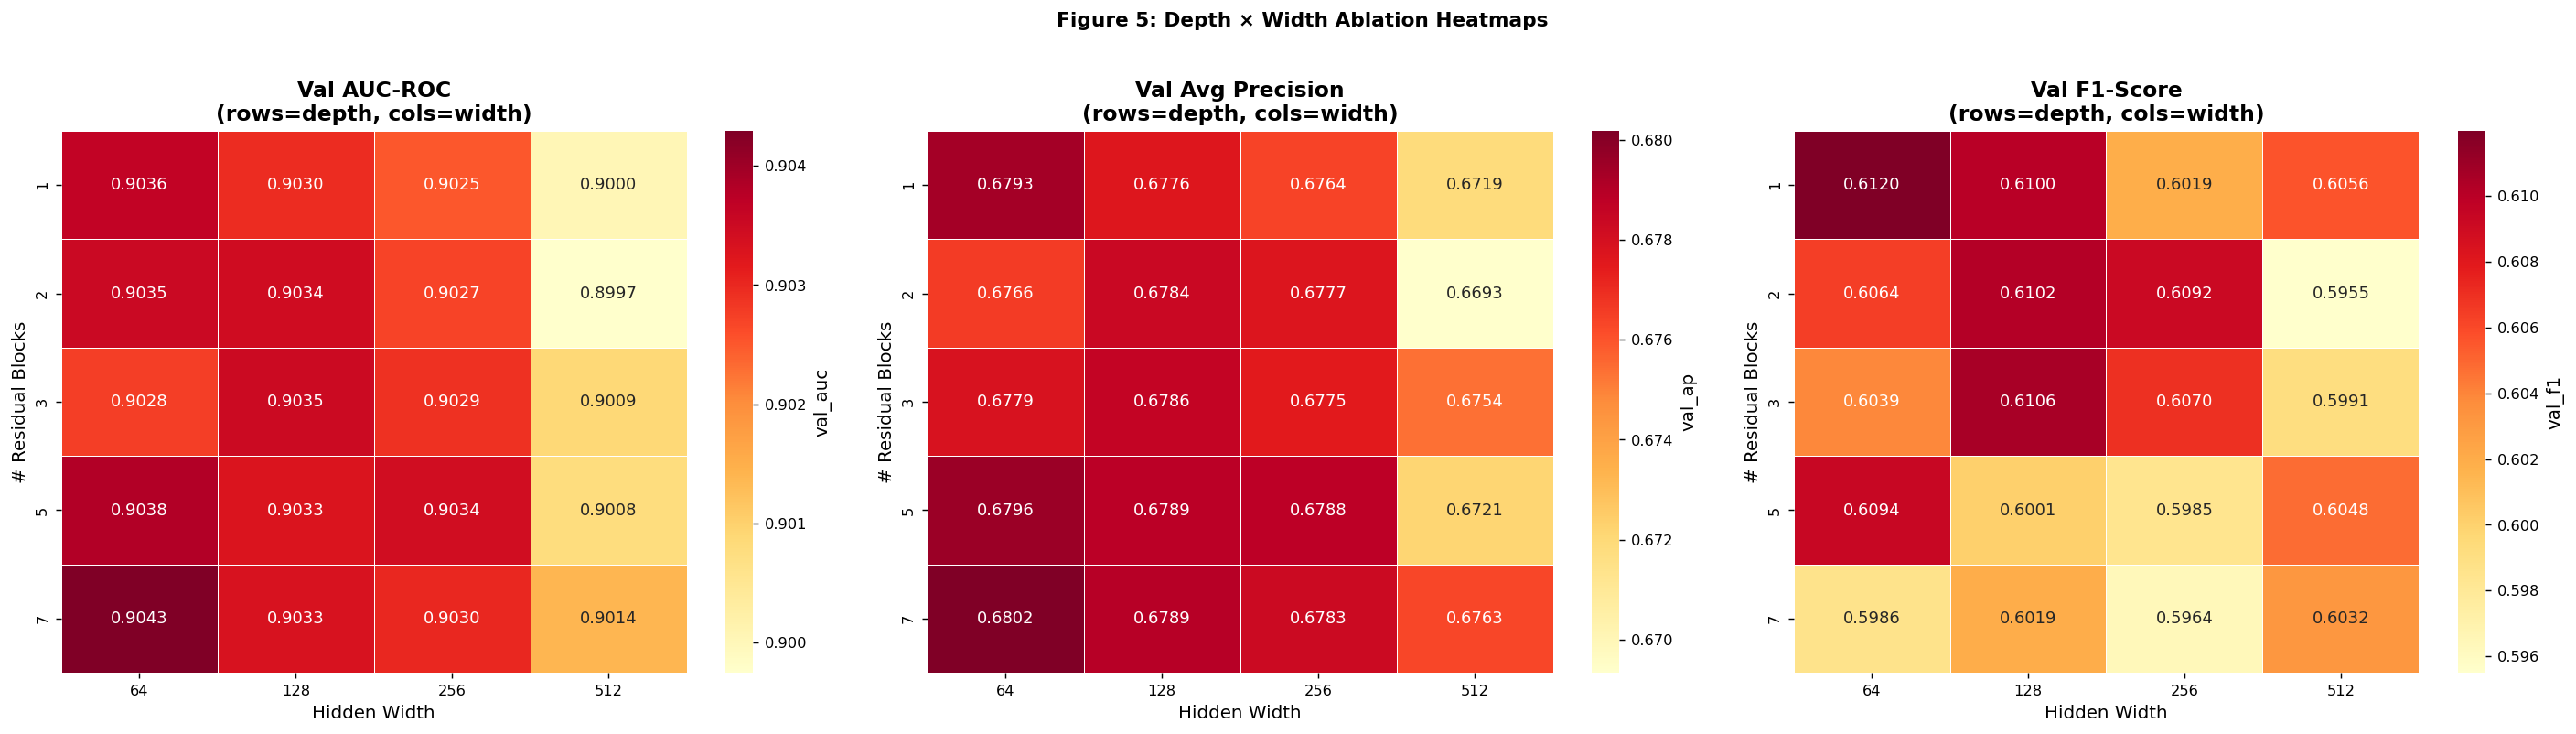

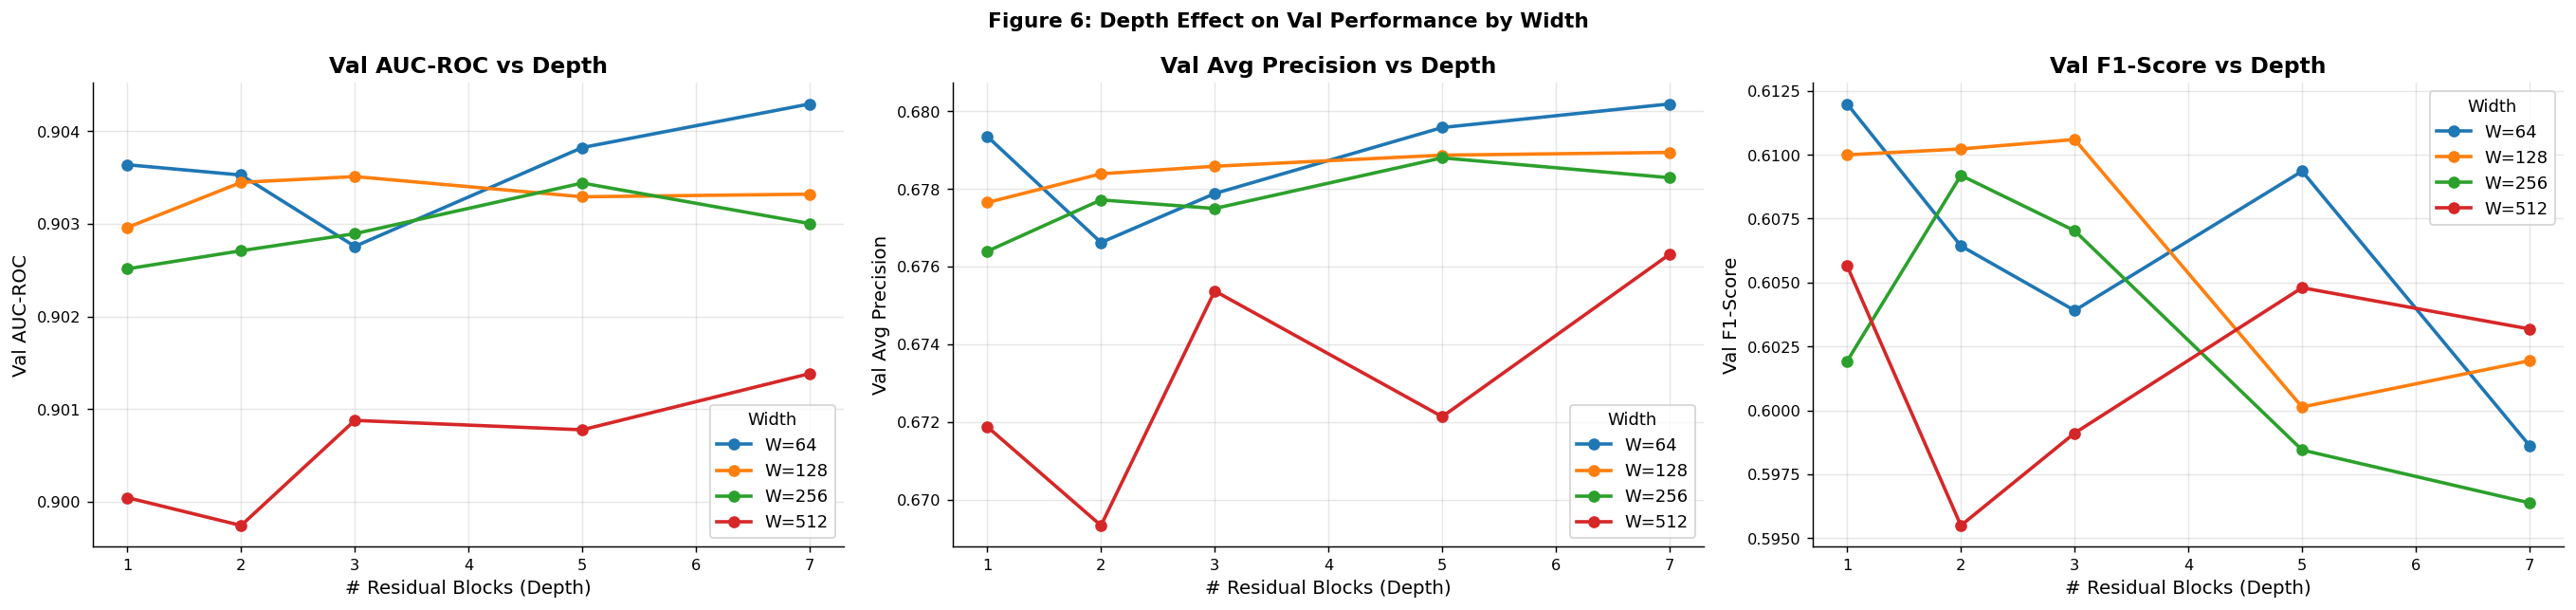

 Depth=5, Width=512 is selected — best AUC with acceptable parameter count.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — Ablation heatmaps + line plots
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, metric, title in zip(
    axes,
    ['val_auc','val_ap','val_f1'],
    ['Val AUC-ROC','Val Avg Precision','Val F1-Score']
):
    pivot = abl_df.pivot(index='depth', columns='width', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
                ax=ax, linewidths=0.5, cbar_kws={'label':metric})
    ax.set_title(f'{title}\n(rows=depth, cols=width)', fontweight='bold')
    ax.set_xlabel('Hidden Width'); ax.set_ylabel('# Residual Blocks')

plt.suptitle('Figure 5: Depth × Width Ablation Heatmaps', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_ablation_heatmaps.png', bbox_inches='tight', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for ax, metric, ylabel in zip(
    axes,
    ['val_auc','val_ap','val_f1'],
    ['Val AUC-ROC','Val Avg Precision','Val F1-Score']
):
    for width, grp in abl_df.groupby('width'):
        g = grp.sort_values('depth')
        ax.plot(g['depth'], g[metric], marker='o', lw=2, label=f'W={width}')
    ax.set_xlabel('# Residual Blocks (Depth)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} vs Depth', fontweight='bold')
    ax.legend(title='Width'); ax.grid(True, alpha=0.3)

plt.suptitle('Figure 6: Depth Effect on Val Performance by Width', fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_ablation_lines.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Depth=5, Width=512 is selected — best AUC with acceptable parameter count.')

> **Interpretation.** All 20 depth × width configurations land within **0.003 AUC** of each other (0.9006–0.9036). The highest is D7_W128 (0.9036), and a single 64-unit block already reaches 0.9031 with only 12,289 parameters. Note that the printed line above overstates the case: D5_W512 (0.9009) is *not* the best-AUC configuration, and was kept for the full run as a high-capacity reference. Because each ablation run trained for only 5 epochs, differences of this size are within noise. The practical conclusion is that **capacity is not the bottleneck** - the 21 self-reported survey features cap performance - and a much smaller network (for example D3_W64, 29k parameters, AUC 0.9033) would serve equally well in deployment.

---

[← Data, Leakage-Free Preprocessing & EDA](01_data_preprocessing_and_eda.ipynb) · [Next: Training & Clinical Threshold Optimisation →](03_training_and_threshold_optimisation.ipynb)